# SQLite + Pandas & Data Analysis Practice

## Connect SQLite to Pandas

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('chinook.db')

## Load Data Into DataFrame

In [5]:
df = pd.read_sql('''
SELECT *
FROM customers
''', conn)

df.head()

,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,NaN,Theodor-Heuss-Straße 34,Stuttgart,NaN,Germany,70174,+49 0711 2842222,NaN,leonekohler@surfeu.de,5
2,3,François,Tremblay,NaN,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,NaN,ftremblay@gmail.com,3
3,4,Bjørn,Hansen,NaN,Ullevålsveien 14,Oslo,NaN,Norway,0171,+47 22 44 22 22,NaN,bjorn.hansen@yahoo.no,4
4,5,František,Wichterlová,JetBrains s.r.o.,Klanova 9/506,Prague,NaN,Czech Republic,14700,+420 2 4172 5555,+420 2 4172 5555,frantisekw@jetbrains.com,4


In [6]:
df.shape

(59, 13)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   CustomerId    59 non-null     int64
 1   FirstName     59 non-null     str  
 2   LastName      59 non-null     str  
 3   Company       10 non-null     str  
 4   Address       59 non-null     str  
 5   City          59 non-null     str  
 6   State         30 non-null     str  
 7   Country       59 non-null     str  
 8   PostalCode    55 non-null     str  
 9   Phone         58 non-null     str  
 10  Fax           12 non-null     str  
 11  Email         59 non-null     str  
 12  SupportRepId  59 non-null     int64
dtypes: int64(2), str(11)
memory usage: 11.7 KB


## Select Only Required Columns

In [8]:
df = pd.read_sql('''
SELECT CustomerId, FirstName, LastName, Country
FROM customers
''', conn)

df.head(20)

,CustomerId,FirstName,LastName,Country
0,1,Luís,Gonçalves,Brazil
1,2,Leonie,Köhler,Germany
2,3,François,Tremblay,Canada
3,4,Bjørn,Hansen,Norway
4,5,František,Wichterlová,Czech Republic
5,6,Helena,Holý,Czech Republic
6,7,Astrid,Gruber,Austria
7,8,Daan,Peeters,Belgium
8,9,Kara,Nielsen,Denmark
9,10,Eduardo,Martins,Brazil


## SQL Filtering + Pandas

In [9]:
df = pd.read_sql('''
SELECT CustomerId, FirstName, LastName, Country
FROM customers
WHERE Country = 'USA'
''', conn)

df.head(20)

,CustomerId,FirstName,LastName,Country
0,16,Frank,Harris,USA
1,17,Jack,Smith,USA
2,18,Michelle,Brooks,USA
3,19,Tim,Goyer,USA
4,20,Dan,Miller,USA
5,21,Kathy,Chase,USA
6,22,Heather,Leacock,USA
7,23,John,Gordon,USA
8,24,Frank,Ralston,USA
9,25,Victor,Stevens,USA


## JOIN Multiple Tables

In [12]:
df = pd.read_sql('''
SELECT *
FROM invoices
''', conn)

df.head()

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2009-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,NaN,Germany,70174,1.98
1,2,4,2009-01-02 00:00:00,Ullevålsveien 14,Oslo,NaN,Norway,0171,3.96
2,3,8,2009-01-03 00:00:00,Grétrystraat 63,Brussels,NaN,Belgium,1000,5.94
3,4,14,2009-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
4,5,23,2009-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86


In [14]:
invoice = pd.read_sql('''
SELECT
c.CustomerId, 
c.FirstName, 
c.LastName, 
i.InvoiceId,
i.InvoiceDate,
i.Total
FROM customers AS c
JOIN invoices AS i
ON c.CustomerId = i.CustomerId
''', conn)

invoice

,CustomerId,FirstName,LastName,InvoiceId,InvoiceDate,Total
0,1,Luís,Gonçalves,98,2010-03-11 00:00:00,3.98
1,1,Luís,Gonçalves,121,2010-06-13 00:00:00,3.96
2,1,Luís,Gonçalves,143,2010-09-15 00:00:00,5.94
3,1,Luís,Gonçalves,195,2011-05-06 00:00:00,0.99
4,1,Luís,Gonçalves,316,2012-10-27 00:00:00,1.98
...,...,...,...,...,...,...
407,59,Puja,Srivastava,45,2009-07-08 00:00:00,5.94
408,59,Puja,Srivastava,97,2010-02-26 00:00:00,1.99
409,59,Puja,Srivastava,218,2011-08-20 00:00:00,1.98
410,59,Puja,Srivastava,229,2011-09-30 00:00:00,13.86


## Sales by Country

In [17]:
sales = pd.read_sql('''
SELECT c.Country, SUM(i.Total) AS Total
FROM customers AS c
JOIN invoices AS i
ON c.CustomerId = i.CustomerID
GROUP BY c.Country
ORDER BY Total DESC

''', conn)

sales

,Country,Total
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


## Visualize Sales by Country

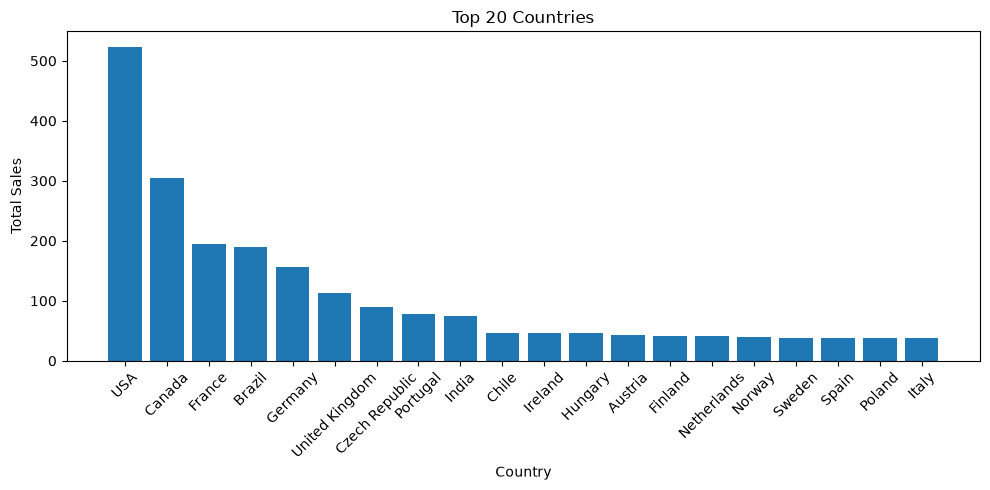

In [25]:
top = sales.head(20)

plt.figure(figsize = (10, 5))

plt.bar(top['Country'], top['Total'])

plt.title('Top 20 Countries')
plt.xlabel('Country')
plt.ylabel('Total Sales')

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

## Monthly Sales Analysis

In [28]:
month = pd.read_sql('''
SELECT strftime('%Y-%m', InvoiceDate) AS month, SUM(Total) AS Total
FROM invoices
GROUP BY month
ORDER BY month
''', conn)

month

,month,Total
0,2009-01,35.64
1,2009-02,37.62
2,2009-03,37.62
3,2009-04,37.62
4,2009-05,37.62
5,2009-06,37.62
6,2009-07,37.62
7,2009-08,37.62
8,2009-09,37.62
9,2009-10,37.62


## Sales Trend

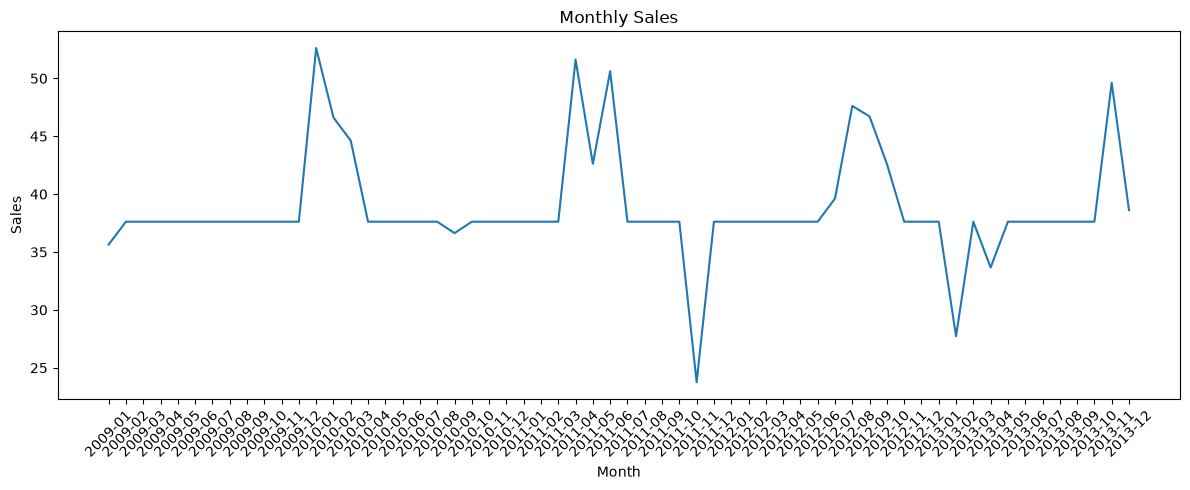

In [34]:
plt.figure(figsize = (12, 5))

plt.plot(month['month'], month['Total'])

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()